In [ ]:
from google.colab import files
files.upload()


Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"vanshsharma7326","key":"9aa3160f885670b2bd3fe74e27ae72bc"}'}

IMPORT KAGGLE

In [ ]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

cp: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory


DOWNLOAD KAGGLE DATASET AND UNZIP

In [ ]:
!kaggle datasets download -d bmadushanirodrigo/fracture-multi-region-x-ray-data
!unzip fracture-multi-region-x-ray-data.zip

Streaming output truncated to the last 5000 lines.
  inflating: Bone_Fracture_Binary_Classification/Bone_Fracture_Binary_Classification/train/not fractured/14-rotated2-rotated2-rotated3 (1).jpg  
  inflating: Bone_Fracture_Binary_Classification/Bone_Fracture_Binary_Classification/train/not fractured/14-rotated2-rotated2-rotated3-rotated1 (1).jpg  
  inflating: Bone_Fracture_Binary_Classification/Bone_Fracture_Binary_Classification/train/not fractured/14-rotated2-rotated2-rotated3-rotated1.jpg  
  inflating: Bone_Fracture_Binary_Classification/Bone_Fracture_Binary_Classification/train/not fractured/14-rotated2-rotated2-rotated3.jpg  
  inflating: Bone_Fracture_Binary_Classification/Bone_Fracture_Binary_Classification/train/not fractured/14-rotated2-rotated2.jpg  
  inflating: Bone_Fracture_Binary_Classification/Bone_Fracture_Binary_Classification/train/not fractured/14-rotated2-rotated3 (1).jpg  
  inflating: Bone_Fracture_Binary_Classification/Bone_Fracture_Binary_Classification/train/

**Load truncated images**:-Helps loading corrupted images

In [ ]:
from PIL import ImageFile
ImageFile.LOAD_TRUNCATED_IMAGES = True

IMPORT LIBRARIES

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMPORT Training Paths and Perform Data Augmentation

In [ ]:
train_path = "Bone_Fracture_Binary_Classification/Bone_Fracture_Binary_Classification/train"
val_path = "Bone_Fracture_Binary_Classification/Bone_Fracture_Binary_Classification/val"

# 🔥 Augmentation (IMPORTANT)
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True,
    shear_range=0.1
)

val_datagen = ImageDataGenerator(rescale=1./255)

train_data = train_datagen.flow_from_directory(
    train_path,
    target_size=(224,224),
    batch_size=32,
    class_mode='binary'
)

val_data = val_datagen.flow_from_directory(
    val_path,
    target_size=(224,224),
    batch_size=32,
    class_mode='binary'
)

print(train_data.class_indices)

Found 9246 images belonging to 2 classes.
Found 829 images belonging to 2 classes.
{'fractured': 0, 'not fractured': 1}


Define Model(CNN) and Layers

This is a totally experimental Space where we can try adding layers or neurons acc. to our need.



In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(224,224,3)),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),
    Dense(128, activation='relu'),
    Dense(1, activation='sigmoid')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


EarlyStopping And Model compilation

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=2,
    restore_best_weights=True
)

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

Training Model And Save model

In [ ]:
import os
if not os.path.exists("DLmodel.h5"):
    print("Training model...")

    history = model.fit(
        train_data,
        validation_data=val_data,
        epochs=5
    )

    model.save("DLmodel.h5")

else:
    print("Loading saved model...")
    from tensorflow.keras.models import load_model
    model = load_model("DLmodel.h5")

Loading saved model...


Resizing image for predictions

In [ ]:
from PIL import Image

def predict_image(img_path):
    img = Image.open(img_path).convert("RGB")
    img = img.resize((224,224))

    img = np.array(img) / 255.0
    img = np.expand_dims(img, axis=0)

    pred = model.predict(img)[0][0]

    print("Raw prediction:", pred)

    # ✅ Correct mapping
    if pred < 0.5:
        label = "Fractured"
        confidence = 1 - pred
    else:
        label = "Normal"
        confidence = pred

    plt.imshow(Image.open(img_path))
    plt.title(f"{label} ({confidence:.4f})")
    plt.axis("off")
    plt.show()

    print("Prediction:", label)
    print("Confidence:", confidence)

Image Predictions from Test Folder of Dataset

1/1 ━━━━━━━━━━━━━━━━━━━━ 16s 16s/step
Raw prediction: 3.5578938e-07


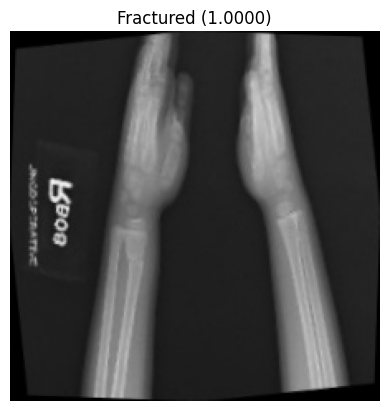

Prediction: Fractured
Confidence: 0.99999964


In [ ]:
import os, random

folder = "Bone_Fracture_Binary_Classification/Bone_Fracture_Binary_Classification/test/fractured"

img = random.choice(os.listdir(folder))
predict_image(os.path.join(folder, img))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
Raw prediction: 1.0


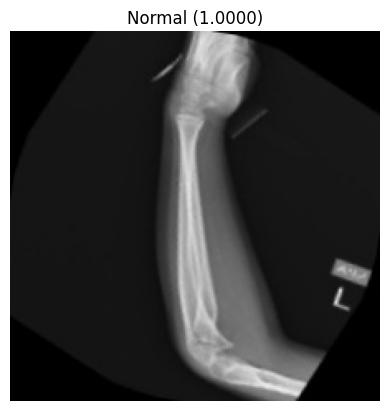

Prediction: Normal
Confidence: 1.0


In [ ]:
folder = "Bone_Fracture_Binary_Classification/Bone_Fracture_Binary_Classification/test/not fractured"

img = random.choice(os.listdir(folder))
predict_image(os.path.join(folder, img))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
Raw prediction: 1.7084835e-08


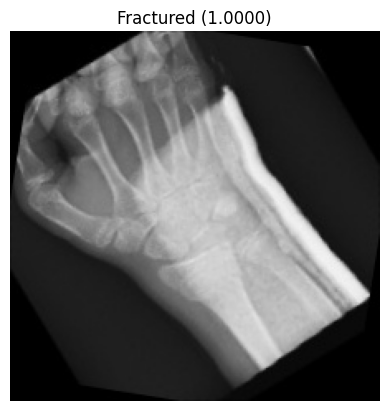

Prediction: Fractured
Confidence: 1.0


In [ ]:
import os, random

folder = "Bone_Fracture_Binary_Classification/Bone_Fracture_Binary_Classification/test/fractured"

img = random.choice(os.listdir(folder))
predict_image(os.path.join(folder, img))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
Raw prediction: 0.73225915


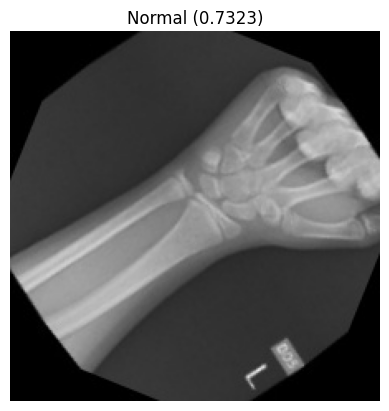

Prediction: Normal
Confidence: 0.73225915


In [ ]:
import os, random

folder = "Bone_Fracture_Binary_Classification/Bone_Fracture_Binary_Classification/test/not fractured"

img = random.choice(os.listdir(folder))
predict_image(os.path.join(folder, img))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
Raw prediction: 0.003340123


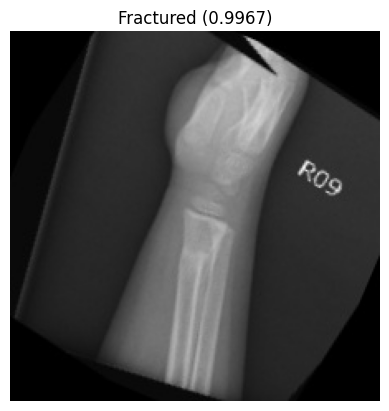

Prediction: Fractured
Confidence: 0.9966599


In [ ]:
import os, random

folder = "Bone_Fracture_Binary_Classification/Bone_Fracture_Binary_Classification/test/fractured"

img = random.choice(os.listdir(folder))
predict_image(os.path.join(folder, img))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
Raw prediction: 0.99806434


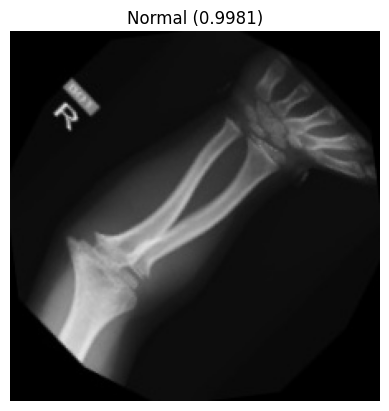

Prediction: Normal
Confidence: 0.99806434


In [ ]:
import os, random

folder = "Bone_Fracture_Binary_Classification/Bone_Fracture_Binary_Classification/test/not fractured"

img = random.choice(os.listdir(folder))
predict_image(os.path.join(folder, img))

Image Predictions from Any other dataset

But model not perform that well on web images as they are not available as on which the model is trained.

Saving 2.jpeg to 2.jpeg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
Raw prediction: 0.0004137154


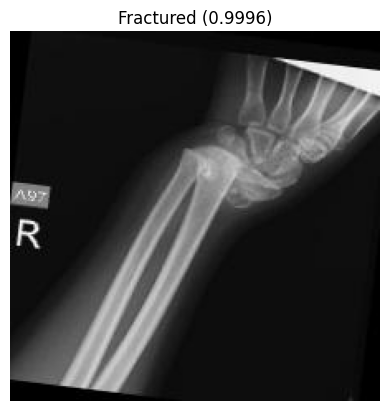

Prediction: Fractured
Confidence: 0.9995863


In [ ]:
from google.colab import files

uploaded = files.upload()

predict_image(list(uploaded.keys())[0])

Saving 3.jpeg to 3.jpeg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
Raw prediction: 0.9998659


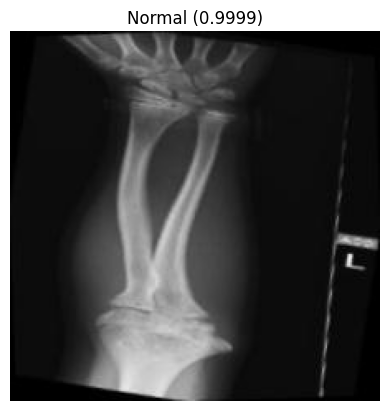

Prediction: Normal
Confidence: 0.9998659


In [ ]:
from google.colab import files

uploaded = files.upload()

predict_image(list(uploaded.keys())[0])

In [ ]:
model.save("model.h5")

**Now using Pretrained Model/Transfer Learning(MobileNetV2)**

Import libraries

In [ ]:
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout

Load model

In [ ]:
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Freezing base model(pre trained layers)

In [ ]:
for layer in base_model.layers:
    layer.trainable = False

Adding custom layers

In [ ]:
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)
output = Dense(1, activation='sigmoid')(x)

model = Model(inputs=base_model.input, outputs=output)

Model compilation

In [ ]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

Model training

In [ ]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=10
)

Epoch 1/10
289/289 ━━━━━━━━━━━━━━━━━━━━ 0s 445ms/step - accuracy: 0.7406 - loss: 0.5329

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


289/289 ━━━━━━━━━━━━━━━━━━━━ 168s 521ms/step - accuracy: 0.8167 - loss: 0.3986 - val_accuracy: 0.8854 - val_loss: 0.2671
Epoch 2/10
289/289 ━━━━━━━━━━━━━━━━━━━━ 121s 421ms/step - accuracy: 0.9159 - loss: 0.2222 - val_accuracy: 0.9288 - val_loss: 0.2030
Epoch 3/10
289/289 ━━━━━━━━━━━━━━━━━━━━ 122s 423ms/step - accuracy: 0.9435 - loss: 0.1500 - val_accuracy: 0.9457 - val_loss: 0.1733
Epoch 4/10
289/289 ━━━━━━━━━━━━━━━━━━━━ 122s 423ms/step - accuracy: 0.9561 - loss: 0.1178 - val_accuracy: 0.9433 - val_loss: 0.1473
Epoch 5/10
289/289 ━━━━━━━━━━━━━━━━━━━━ 126s 436ms/step - accuracy: 0.9655 - loss: 0.0924 - val_accuracy: 0.9517 - val_loss: 0.1342
Epoch 6/10
289/289 ━━━━━━━━━━━━━━━━━━━━ 128s 442ms/step - accuracy: 0.9701 - loss: 0.0803 - val_accuracy: 0.9566 - val_loss: 0.1187
Epoch 7/10
289/289 ━━━━━━━━━━━━━━━━━━━━ 122s 420ms/step - accuracy: 0.9719 - loss: 0.0784 - val_accuracy: 0.9614 - val_loss: 0.1117
Epoch 8/10
289/289 ━━━━━━━━━━━━━━━━━━━━ 121s 420ms/step - accuracy: 0.9767 - loss: 0.06

Summary

In [ ]:
model.summary()

Model: "functional_15"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer_1[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,750,277 (10.49 MB)

 Trainable params: 164,097 (641.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

 Optimizer params: 328,196 (1.25 MB)

Testing After using tranfer learning

1/1 ━━━━━━━━━━━━━━━━━━━━ 12s 12s/step
Raw prediction: 6.447055e-05


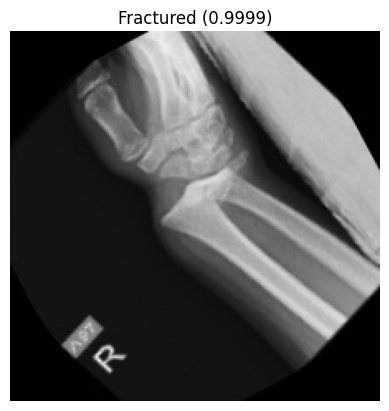

Prediction: Fractured
Confidence: 0.9999355


In [ ]:
import os, random

folder = "Bone_Fracture_Binary_Classification/Bone_Fracture_Binary_Classification/test/fractured"

img = random.choice(os.listdir(folder))
predict_image(os.path.join(folder, img))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
Raw prediction: 0.9996557


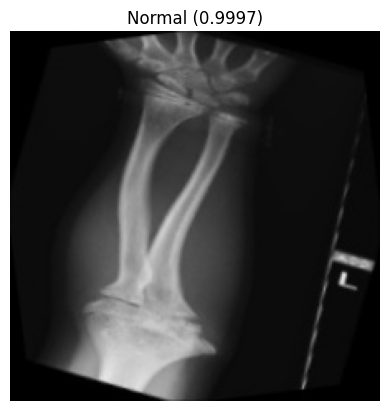

Prediction: Normal
Confidence: 0.9996557


In [ ]:
import os, random

folder = "Bone_Fracture_Binary_Classification/Bone_Fracture_Binary_Classification/test/not fractured"

img = random.choice(os.listdir(folder))
predict_image(os.path.join(folder, img))

Accuracy

In [ ]:
print(history.history['accuracy'])
print(history.history['val_accuracy'])

[0.8166775107383728, 0.9158555269241333, 0.9435431361198425, 0.9560891389846802, 0.9654985666275024, 0.9701492786407471, 0.9718797206878662, 0.976746678352356, 0.9794505834579468, 0.9756651520729065]
[0.885404109954834, 0.9288299083709717, 0.9457177519798279, 0.9433051943778992, 0.9517490863800049, 0.9565742015838623, 0.961399257183075, 0.965018093585968, 0.9662243723869324, 0.9686369299888611]


In [ ]:
val_data.reset()

Make Shuffle images of when evaluating

In [ ]:
val_data = val_datagen.flow_from_directory(
    val_path,
    target_size=(224,224),
    batch_size=32,
    class_mode='binary',
    shuffle=False
)

Found 829 images belonging to 2 classes.


In [ ]:
val_data.reset()

y_true = val_data.classes
y_pred_prob = model.predict(val_data).ravel()
y_pred = (y_pred_prob > 0.5).astype(int)

 9/26 ━━━━━━━━━━━━━━━━━━━━ 2s 165ms/step

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


26/26 ━━━━━━━━━━━━━━━━━━━━ 5s 190ms/step


In [ ]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_true, y_pred)
print("Correct Accuracy:", accuracy)

Correct Accuracy: 0.9686369119420989


Important Evaluations (Accuracy,AUC,ROC,Confusion matrix)

 8/26 ━━━━━━━━━━━━━━━━━━━━ 8s 492ms/step

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


26/26 ━━━━━━━━━━━━━━━━━━━━ 11s 361ms/step
✅ Accuracy: 0.9686369119420989
✅ AUC Score: 0.9916467636486455


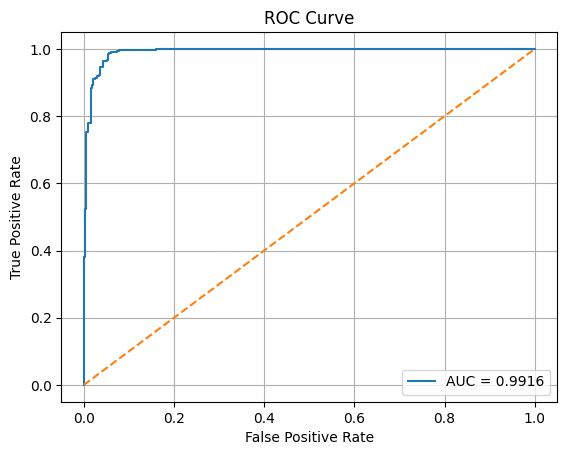

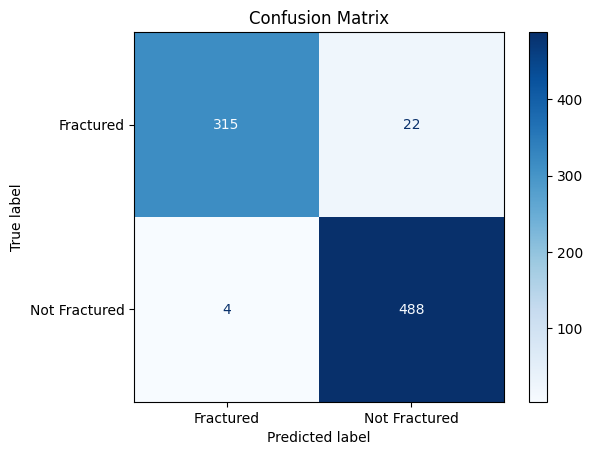

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, roc_auc_score, roc_curve, confusion_matrix, ConfusionMatrixDisplay

# IMPORTANT
val_data.reset()

# True labels
y_true = val_data.classes

# Predictions
y_pred_prob = model.predict(val_data).ravel()
y_pred = (y_pred_prob > 0.5).astype(int)

# -------------------------
# Accuracy
# -------------------------
accuracy = accuracy_score(y_true, y_pred)
print("✅ Accuracy:", accuracy)

# -------------------------
# AUC Score
# -------------------------
auc = roc_auc_score(y_true, y_pred_prob)
print("✅ AUC Score:", auc)

# -------------------------
# ROC Curve
# -------------------------
fpr, tpr, _ = roc_curve(y_true, y_pred_prob)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {auc:.4f}")
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid()
plt.show()

# -------------------------
# Confusion Matrix
# -------------------------
cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(cm, display_labels=["Fractured", "Not Fractured"])
disp.plot(cmap="Blues")

plt.title("Confusion Matrix")
plt.show()

Graphs of Model Accuracy and Model Loss

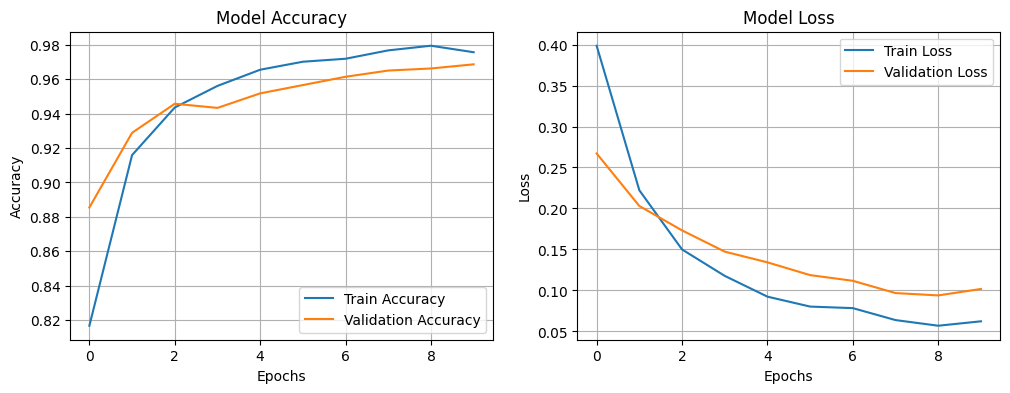

In [ ]:
plt.figure(figsize=(12,4))

# Accuracy
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title("Model Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.grid()

# Loss
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title("Model Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid()

plt.show()

Saving the New model (Mobilenetv2 Based)

In [ ]:
model.save("DLmodel.h5")

Testing on whole Dataset test folder

In [ ]:
test_path = "Bone_Fracture_Binary_Classification/Bone_Fracture_Binary_Classification/test"

test_datagen = ImageDataGenerator(rescale=1./255)

test_data = test_datagen.flow_from_directory(
    test_path,
    target_size=(224,224),
    batch_size=32,
    class_mode='binary',
    shuffle=False   # VERY IMPORTANT
)

Found 506 images belonging to 2 classes.


In [ ]:
y_pred_prob = model.predict(test_data)
y_pred_prob = y_pred_prob.ravel()

y_pred = (y_pred_prob > 0.5).astype(int)

16/16 ━━━━━━━━━━━━━━━━━━━━ 29s 1s/step


In [ ]:
y_true = test_data.classes

Complete test folder accuracy

In [ ]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_true, y_pred)
print("Test Accuracy:", accuracy)

Test Accuracy: 0.9920948616600791


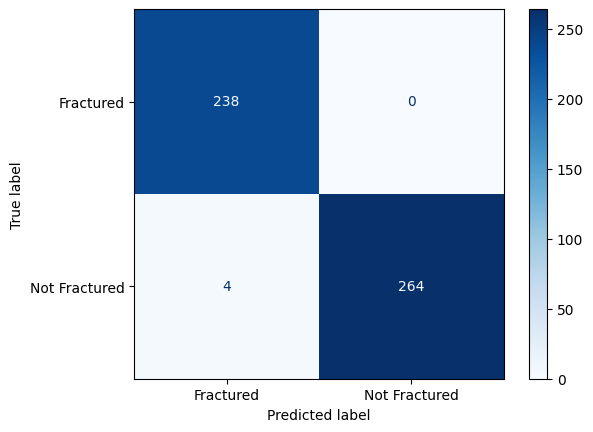

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(cm, display_labels=["Fractured", "Not Fractured"])
disp.plot(cmap="Blues")
plt.show()

**Time Complexity**

In [ ]:
import time

start_time = time.time()

history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=10
)

end_time = time.time()

training_time = end_time - start_time

print("Total Training Time:", training_time, "seconds")
print("Training Time (minutes):", training_time/60)

Epoch 1/10
289/289 ━━━━━━━━━━━━━━━━━━━━ 0s 457ms/step - accuracy: 0.9782 - loss: 0.0613

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


289/289 ━━━━━━━━━━━━━━━━━━━━ 173s 533ms/step - accuracy: 0.9789 - loss: 0.0590 - val_accuracy: 0.9542 - val_loss: 0.1066
Epoch 2/10
289/289 ━━━━━━━━━━━━━━━━━━━━ 123s 426ms/step - accuracy: 0.9817 - loss: 0.0503 - val_accuracy: 0.9686 - val_loss: 0.1010
Epoch 3/10
289/289 ━━━━━━━━━━━━━━━━━━━━ 124s 427ms/step - accuracy: 0.9835 - loss: 0.0450 - val_accuracy: 0.9723 - val_loss: 0.0842
Epoch 4/10
289/289 ━━━━━━━━━━━━━━━━━━━━ 126s 434ms/step - accuracy: 0.9830 - loss: 0.0511 - val_accuracy: 0.9759 - val_loss: 0.0732
Epoch 5/10
289/289 ━━━━━━━━━━━━━━━━━━━━ 124s 429ms/step - accuracy: 0.9820 - loss: 0.0504 - val_accuracy: 0.9686 - val_loss: 0.0901
Epoch 6/10
289/289 ━━━━━━━━━━━━━━━━━━━━ 123s 426ms/step - accuracy: 0.9846 - loss: 0.0464 - val_accuracy: 0.9698 - val_loss: 0.0842
Epoch 7/10
289/289 ━━━━━━━━━━━━━━━━━━━━ 127s 440ms/step - accuracy: 0.9835 - loss: 0.0481 - val_accuracy: 0.9771 - val_loss: 0.0859
Epoch 8/10
289/289 ━━━━━━━━━━━━━━━━━━━━ 131s 452ms/step - accuracy: 0.9832 - loss: 0.04